<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/gru_optimizations/1gru_1dense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Bidirectional
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

TEST_SET_DAYS = 60
VAL_DAYS = 90
N_SPLITS = 4
N_TIMESTEPS = 7

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

GRU_EPOCHS = 50
GRU_BATCH_SIZE = 32

SEARCH_SPACE_GRU_LR = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
SEARCH_SPACE_GRU_UNITS = [32, 64, 128, 256]

In [12]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

# ================== GRU MODEL ==================
def build_bigru_model(input_shape_gru, lr, units):
    gru_input = Input(shape=input_shape_gru, name='gru_input')

    bigru_out1 = Bidirectional(GRU(units, return_sequences=True))(gru_input)
    bigru_out1 = Dropout(0.2)(bigru_out1)

    dense_hidden1 = Dense(units // 2, activation='elu')(bigru_out1)

    output = Dense(1, activation='linear', name='output')(dense_hidden1)

    model = Model(inputs=gru_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def save_static_plot(history, center_name, meal_period):
    output_dir = 'plots'
    os.makedirs(output_dir, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss (MSE)', color='blue', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', lw=2)
    if 'mae' in history.history:
        plt.plot(history.history['mae'], label='Train MAE', color='green', lw=2)
    if 'val_mae' in history.history:
        plt.plot(history.history['val_mae'], label='Validation MAE', color='red', lw=2)

    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Metric Value')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{safe_name}_{meal_period}_metrics.png")
    plt.close()

def plot_loss_curves(history, center_name, meal_period):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss (MSE)', color='blue', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', lw=2)
    plt.title(f'Loss Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Loss (MSE)')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

In [13]:
def random_search_tune(X_train_full, Y_train_full, tscv, raw_target_col,
                       numeric_features, categorical_features,
                       lr_list, units_list, n_trials=12):
    """
    Randomly sample n_trials combinations of (lr, units) for GRU.
    Returns best (avg_cv_rmse, best_params).
    """
    # Build search grid
    grid = list(itertools.product(lr_list, units_list))
    combos = random.sample(grid, min(n_trials, len(grid)))

    best_rmse = float('inf')
    best_params = None

    for params in combos:
        lr, units = params
        fold_rmses = []

        # Cross-validation loop
        for train_idx, val_idx in tscv.split(X_train_full):
            # Split train/val
            X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
            Y_val = Y_train_full.iloc[val_idx][raw_target_col]

            # Scale numeric features
            scaler = RobustScaler()
            X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
            X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

            # Combine numeric + categorical
            X_train_cv_scaled = pd.concat(
                [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
                 X_train_cv_raw[categorical_features]], axis=1)
            X_val_scaled = pd.concat(
                [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
                 X_val_raw[categorical_features]], axis=1)

            # Sequence creation
            X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
            X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)

            # Skip empty folds
            if len(X_seq_train) == 0 or len(X_seq_val) == 0:
                continue

            # Train GRU
            tf.keras.backend.clear_session()
            gru_model = build_bigru_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
            es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
            gru_model.fit(X_seq_train, Y_seq_train,
                          validation_data=(X_seq_val, Y_seq_val),
                          epochs=GRU_EPOCHS, batch_size=GRU_BATCH_SIZE,
                          callbacks=[es_callback], verbose=0)

            # Predict and score
            y_pred_val = gru_model.predict(X_seq_val, verbose=0).flatten()

            # Align lengths explicitly
            min_len = min(len(Y_seq_val), len(y_pred_val))
            if min_len == 0:
                continue
            Y_seq_val = Y_seq_val[:min_len]
            y_pred_val = y_pred_val[:min_len]

            rmse = np.sqrt(mean_squared_error(Y_seq_val, y_pred_val))
            fold_rmses.append(rmse)

        # Track best params
        if fold_rmses:
            avg_rmse = np.mean(fold_rmses)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = params

    return best_rmse, best_params

In [14]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    summary_rows = []

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        best_cv_rmse, best_params = random_search_tune(
            X_train_full=X_train_full, Y_train_full=Y_train_full, tscv=tscv,
            raw_target_col=raw_target_col, numeric_features=numeric_features,
            categorical_features=categorical_features,
            lr_list=SEARCH_SPACE_GRU_LR, units_list=SEARCH_SPACE_GRU_UNITS, n_trials=12
        )
        best_lr, best_units = best_params
        print(f"✅ Optimal Params for {center_name} - {meal_period}: "
              f"LR={best_lr}, Units={best_units} | CV RMSE={best_cv_rmse:.2f}")

        # Final training data
        final_scaler = RobustScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features, index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        run_id = f"{center_name}_{meal_period}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
        log_dir = os.path.join("logs", "fit", run_id)
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

        tf.keras.backend.clear_session()
        final_gru_model = build_bigru_model((N_TIMESTEPS, X_train_tb.shape[2]), best_lr, best_units)

        print(f"📊 Training Final GRU Model for {center_name} - {meal_period} "
              f"(LR={best_lr}, Units={best_units})")

        history = final_gru_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=GRU_EPOCHS,
            batch_size=GRU_BATCH_SIZE,
            callbacks=[tb_callback, es_callback],
            verbose=0
        )

        # Save curves and show loss plot
        save_static_plot(history, center_name, meal_period)
        plot_loss_curves(history, center_name, meal_period)

        # Test evaluation
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features, index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_gru = final_gru_model.predict(X_seq_test, verbose=0).flatten()
        Y_test_actual = df_test_full[raw_target_col].values[:len(y_test_gru)]

        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:len(y_test_gru)],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_gru
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

        summary_rows.append({
            'Center': center_name,
            'Meal_Period': meal_period,
            'Best_LR': best_lr,
            'Best_Units': best_units,
            'CV_RMSE': round(best_cv_rmse, 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    os.makedirs('plots', exist_ok=True)
    summary_path = os.path.join('plots', f"{center_name.replace(' ', '_')}_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"📄 Saved summary: {summary_path}")
    print(summary_df)


================= Revenue Centre 1 =================
✅ Optimal Params for Revenue Centre 1 - BreakFast: LR=0.01, Units=256 | CV RMSE=751.63
📊 Training Final GRU Model for Revenue Centre 1 - BreakFast (LR=0.01, Units=256)


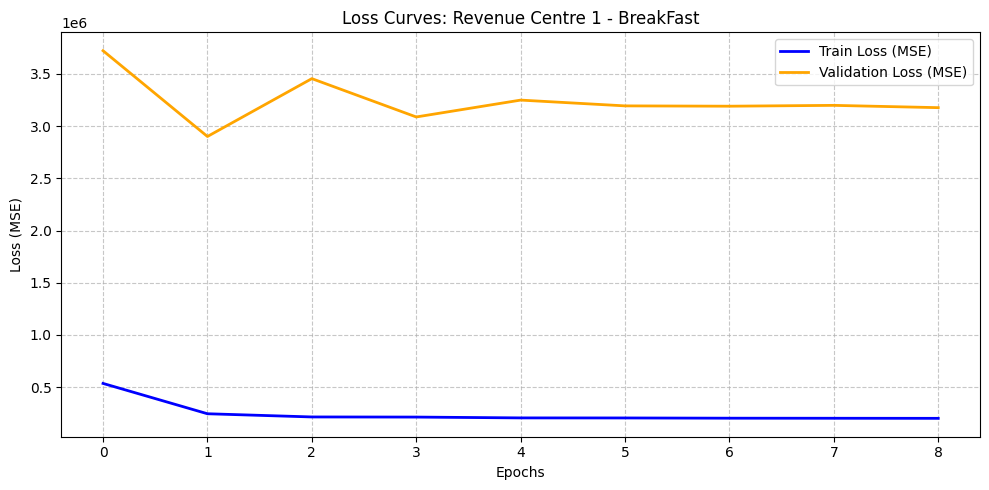

⚠️ Skipping 0: All arrays must be of the same length


In [15]:

# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    for center_id in range(0, 1):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")
